In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from model import GCVTP


def load_checkpoint_model(checkpoint_path, device='cpu'):
    """
    Loads a saved checkpoint, auto-inferring the architecture (hidden
    size, layer count, feature width, forecast horizon) from the saved
    state dict -- so you don't have to remember which --hidden /
    --n-layers flags a given run used.
    Returns (model in eval mode, norm_scale, metadata dict).
    """
    ckpt = torch.load(checkpoint_path, map_location=device)
    sd = ckpt['model_state_dict']

    vessel_in = sd['gnn.vessel_proj.weight'].shape[1]
    hidden = sd['gnn.vessel_proj.weight'].shape[0]
    mesh_in = sd['gnn.mesh_proj.weight'].shape[1]
    n_layers = len([k for k in sd if k.startswith('temporal.layers.') and k.endswith('.attn.qkv.weight')])
    future_len = sd['head.net.4.weight'].shape[0] // 2
    max_cache_len = sd['temporal.pos_embed'].shape[1]

    model = GCVTP(mesh_in=mesh_in, vessel_in=vessel_in, hidden=hidden,
                  future_len=future_len, n_layers=n_layers,
                  max_cache_len=max_cache_len).to(device)
    model.load_state_dict(sd)
    model.eval()

    meta = {'epoch': ckpt.get('epoch'), 'avg_loss': ckpt.get('avg_loss'),
            'hidden': hidden, 'n_layers': n_layers, 'vessel_in': vessel_in,
            'future_len': future_len}
    return model, ckpt['norm_scale'], meta


def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def plot_prediction(model, dataset, idx, norm_scale, land_polygons, ports,
                     n_samples=32, min_window_deg=0.05, figsize=(9, 8), ax=None):
    """
    Plots one window: observed context (black), sampled predicted futures
    (faint blue), and ground truth (red). Converts the model's raw
    normalized-delta output back to absolute coordinates. Enforces a
    minimum zoom window so a near-stationary case doesn't get blown up
    to fill the frame and look artificially chaotic.
    """
    ctx, target = dataset[idx]
    ego_idx = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
    last_pos = ctx[-1]['vessel'].x[ego_idx[-1], :2]

    with torch.no_grad():
        samples = model(ctx, ego_idx, n_samples=n_samples, training=False)
        samples_real = samples * norm_scale + last_pos

    context_xy = np.array([d['vessel'].x[ego_idx[t], :2].cpu().numpy() for t, d in enumerate(ctx)])
    samples_np = samples_real[0].cpu().numpy()
    truth_np = target.cpu().numpy()
    last_np = last_pos.cpu().numpy()

    disp_km = haversine_km(last_np[0], last_np[1], truth_np[-1, 0], truth_np[-1, 1])
    center = samples_np[:, -1, :].mean(axis=0)
    err_km = haversine_km(center[0], center[1], truth_np[-1, 0], truth_np[-1, 1])
    spread_km = np.mean([haversine_km(center[0], center[1], p[0], p[1]) for p in samples_np[:, -1, :]])

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    ax.set_facecolor('#cfe8f3')
    for poly in land_polygons:
        xs, ys = poly.exterior.xy
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='#d8c39a',
                                 edgecolor='#8a7350', linewidth=0.5, zorder=1))
    ax.scatter([p[0] for p in ports], [p[1] for p in ports], s=30, c='black',
               marker='^', zorder=2, label='port')

    ax.plot(context_xy[:, 0], context_xy[:, 1], c='black', marker='o', markersize=4,
            linewidth=1.5, label='observed context', zorder=3)
    for s in range(samples_np.shape[0]):
        path = np.vstack([context_xy[-1:], samples_np[s]])
        ax.plot(path[:, 0], path[:, 1], c='steelblue', alpha=0.25, linewidth=1,
                zorder=2, label='predicted samples' if s == 0 else None)
    truth_path = np.vstack([context_xy[-1:], truth_np])
    ax.plot(truth_path[:, 0], truth_path[:, 1], c='red', marker='*', markersize=8,
            linewidth=2, label='ground truth', zorder=4)

    all_xy = np.vstack([context_xy, samples_np.reshape(-1, 2), truth_np])
    lon_range = max(all_xy[:, 0].max() - all_xy[:, 0].min(), min_window_deg)
    lat_range = max(all_xy[:, 1].max() - all_xy[:, 1].min(), min_window_deg)
    cx, cy = all_xy[:, 0].mean(), all_xy[:, 1].mean()
    ax.set_xlim(cx - lon_range/2 - 0.01, cx + lon_range/2 + 0.01)
    ax.set_ylim(cy - lat_range/2 - 0.01, cy + lat_range/2 + 0.01)
    ax.set_aspect('equal')
    ax.set_title(f'moved {disp_km:.2f}km | err {err_km:.2f}km | spread {spread_km:.2f}km', fontsize=10)
    return fig, {'disp_km': disp_km, 'err_km': err_km, 'spread_km': spread_km}


# ---- load and plot ----
model, norm_scale, meta = load_checkpoint_model('checkpoints/small_checkpoint.pt', device=device)
print('checkpoint:', meta)

# grid of 6 windows: 3 clearly moving, 3 near-stationary, to see both regimes
moving, stationary = [], []
for i in range(len(combined)):
    ctx_i, target_i = combined[i]
    ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
    lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2].cpu().numpy()
    tf = target_i[-1].cpu().numpy()
    d = haversine_km(lp[0], lp[1], tf[0], tf[1])
    (moving if d > 3.0 else stationary).append(i)
    if len(moving) >= 3 and len(stationary) >= 3:
        break

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, i in zip(axes.flat, moving[:3] + stationary[:3]):
    plot_prediction(model, combined, i, norm_scale, land_polygons, ports, ax=ax)
fig.suptitle('Top: moving vessels | Bottom: near-stationary vessels', fontsize=13)
fig.tight_layout()
plt.show()

checkpoint: {'epoch': 49, 'avg_loss': 0.6181944589631362, 'hidden': 64, 'n_layers': 3, 'vessel_in': 12, 'future_len': 4}


NameError: name 'combined' is not defined

In [4]:
import numpy as np
import torch
from scipy.spatial import cKDTree
from torch.utils.data import ConcatDataset

from coastline import load_land_polygons, load_ports, DMA_BOUNDS
from mesh import sample_domain_points, build_mesh
from ais_ingest import (
    load_dma_ais_csv, resample_to_snapshots, build_snapshot_sequence,
    select_ego_vessels_stratified,
)
from graph_data import VesselSequenceDataset
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
bounds = DMA_BOUNDS

# --- coastline, ports, mesh ---
land_polygons = load_land_polygons(bounds, natural_earth_path="data/ne_10m_land/ne_10m_land.shp")
ports = load_ports("data/ports_denmark.csv", bounds)
pts, land_flags = sample_domain_points(bounds, land_polygons, ports)
mesh_node_features, mesh_edge_index, _ = build_mesh(pts, land_flags, ports)
mesh_x_tensor = torch.as_tensor(mesh_node_features, dtype=torch.float, device='cpu')
mesh_edge_tensor = torch.as_tensor(mesh_edge_index, dtype=torch.long, device='cpu')
mesh_tree = cKDTree(mesh_node_features[:, :2])
print(f"mesh: {mesh_node_features.shape[0]} nodes, {mesh_edge_index.shape[1]} edges")

# --- AIS data ---
ais_path = "/scratch/jtb3sud/maritime/ais/aisdk-2026-08-25.csv"
ais_df = load_dma_ais_csv(ais_path, bounds, pd.Timestamp.min, pd.Timestamp.max)
ais_snapshots = resample_to_snapshots(ais_df, interval_minutes=15)
print(f"AIS: {len(ais_df)} records, {len(ais_snapshots)} timestamps")

# --- a modest vessel sample (enough to find interesting windows, fast to build) ---
good_vessels = select_ego_vessels_stratified(ais_df, min_pings=40, sog_threshold_knots=2.0,
                                              n_underway=20, n_stationary=20)

datasets = []
for ego_mmsi in good_vessels.index:
    snaps, ego_steps = build_snapshot_sequence(
        ais_snapshots, mesh_node_features, mesh_edge_index, ego_mmsi,
        mesh_x_tensor=mesh_x_tensor, mesh_edge_tensor=mesh_edge_tensor, mesh_tree=mesh_tree,
    )
    snaps = [d.to(device) for d in snaps]
    ds = VesselSequenceDataset(snaps, ego_steps, seq_len=4, future_len=4)
    if len(ds) > 0:
        datasets.append(ds)

combined = ConcatDataset(datasets)
print(f"windows: {len(combined)} across {len(datasets)} vessels")

mesh: 5581 nodes, 16717 edges
AIS: 29204133 records, 96 timestamps
windows: 1356 across 35 vessels


found 3 moving, 19 stationary candidates


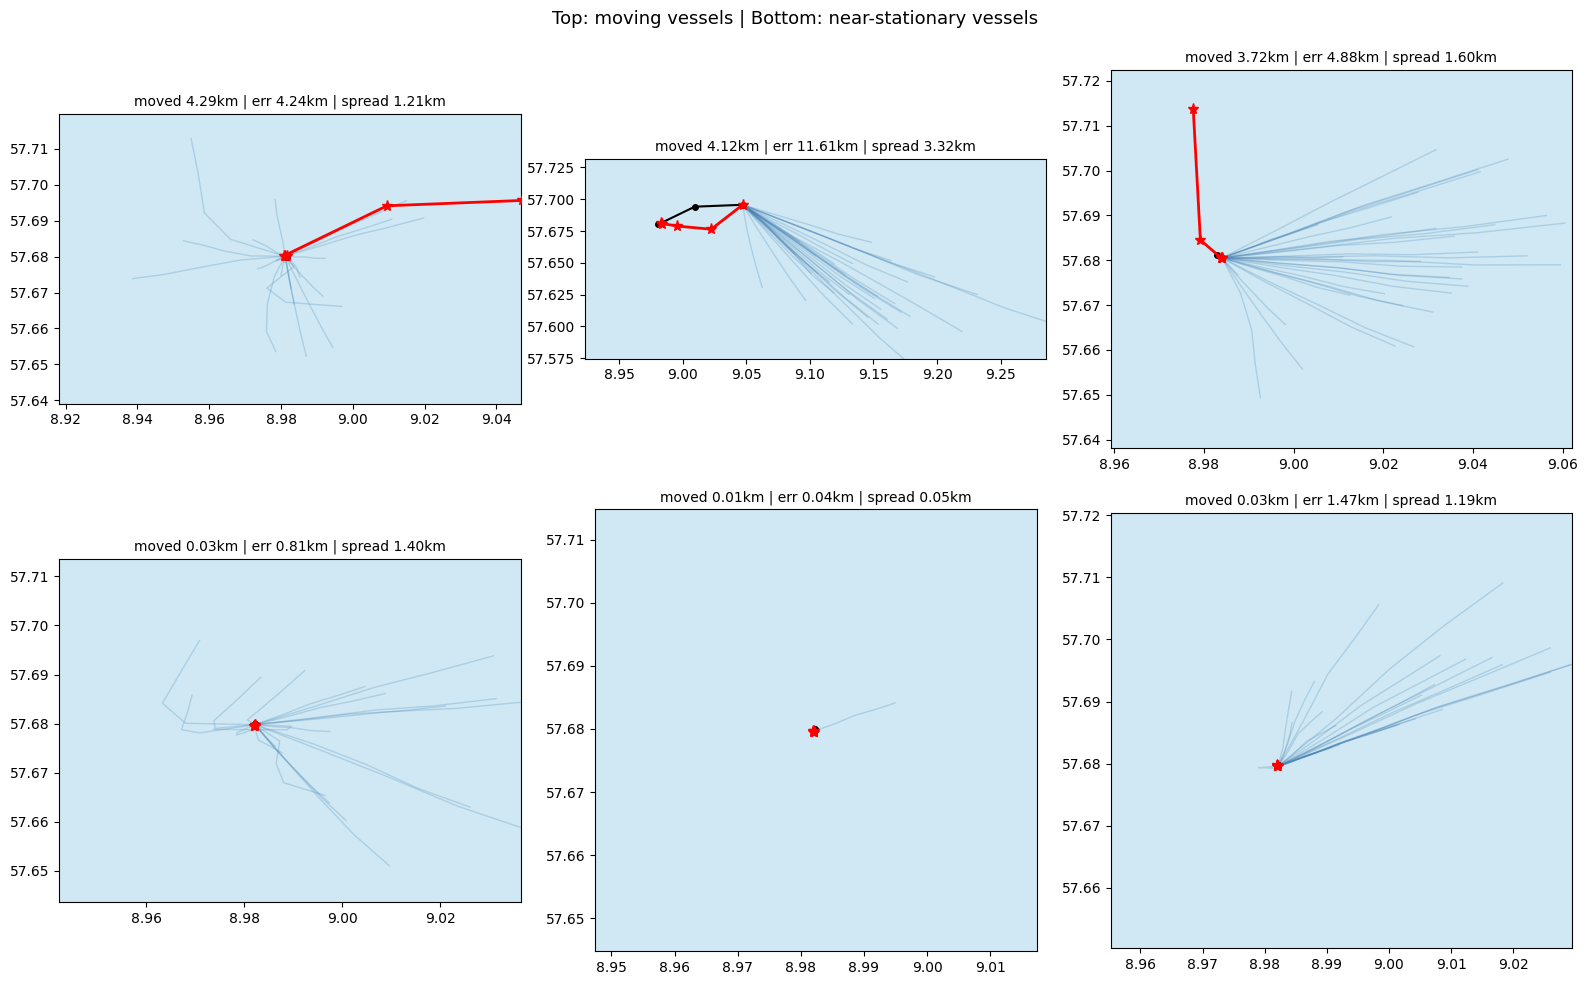

In [5]:
# grid of 6 windows: 3 clearly moving, 3 near-stationary, to see both regimes
moving, stationary = [], []
for i in range(len(combined)):
    ctx_i, target_i = combined[i]
    ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
    lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2].cpu().numpy()
    tf = target_i[-1].cpu().numpy()
    d = haversine_km(lp[0], lp[1], tf[0], tf[1])
    (moving if d > 3.0 else stationary).append(i)
    if len(moving) >= 3 and len(stationary) >= 3:
        break

print(f"found {len(moving)} moving, {len(stationary)} stationary candidates")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, i in zip(axes.flat, moving[:3] + stationary[:3]):
    plot_prediction(model, combined, i, norm_scale, land_polygons, ports, ax=ax)
fig.suptitle('Top: moving vessels | Bottom: near-stationary vessels', fontsize=13)
fig.tight_layout()
plt.show()

In [6]:
errs, disps = [], []
with torch.no_grad():
    for i in range(len(combined)):
        ctx_i, target_i = combined[i]
        ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
        lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2]
        s = model(ctx_i, ego_i, n_samples=32, training=False) * norm_scale + lp
        c = s[0, :, -1, :].mean(dim=0).cpu().numpy()
        tf = target_i[-1].cpu().numpy()
        lpn = lp.cpu().numpy()
        d = haversine_km(lpn[0], lpn[1], tf[0], tf[1])
        if d > 1.0:
            disps.append(d)
            errs.append(haversine_km(c[0], c[1], tf[0], tf[1]))

errs, disps = np.array(errs), np.array(disps)
print(f"n moving: {len(errs)}")
print(f"model mean error: {errs.mean():.2f}km")
print(f"trivial baseline: {disps.mean():.2f}km")
print(f"beats baseline: {100*(errs < disps).mean():.1f}%")

n moving: 505
model mean error: 4.43km
trivial baseline: 9.77km
beats baseline: 84.0%


426 moving windows, 930 stationary windows


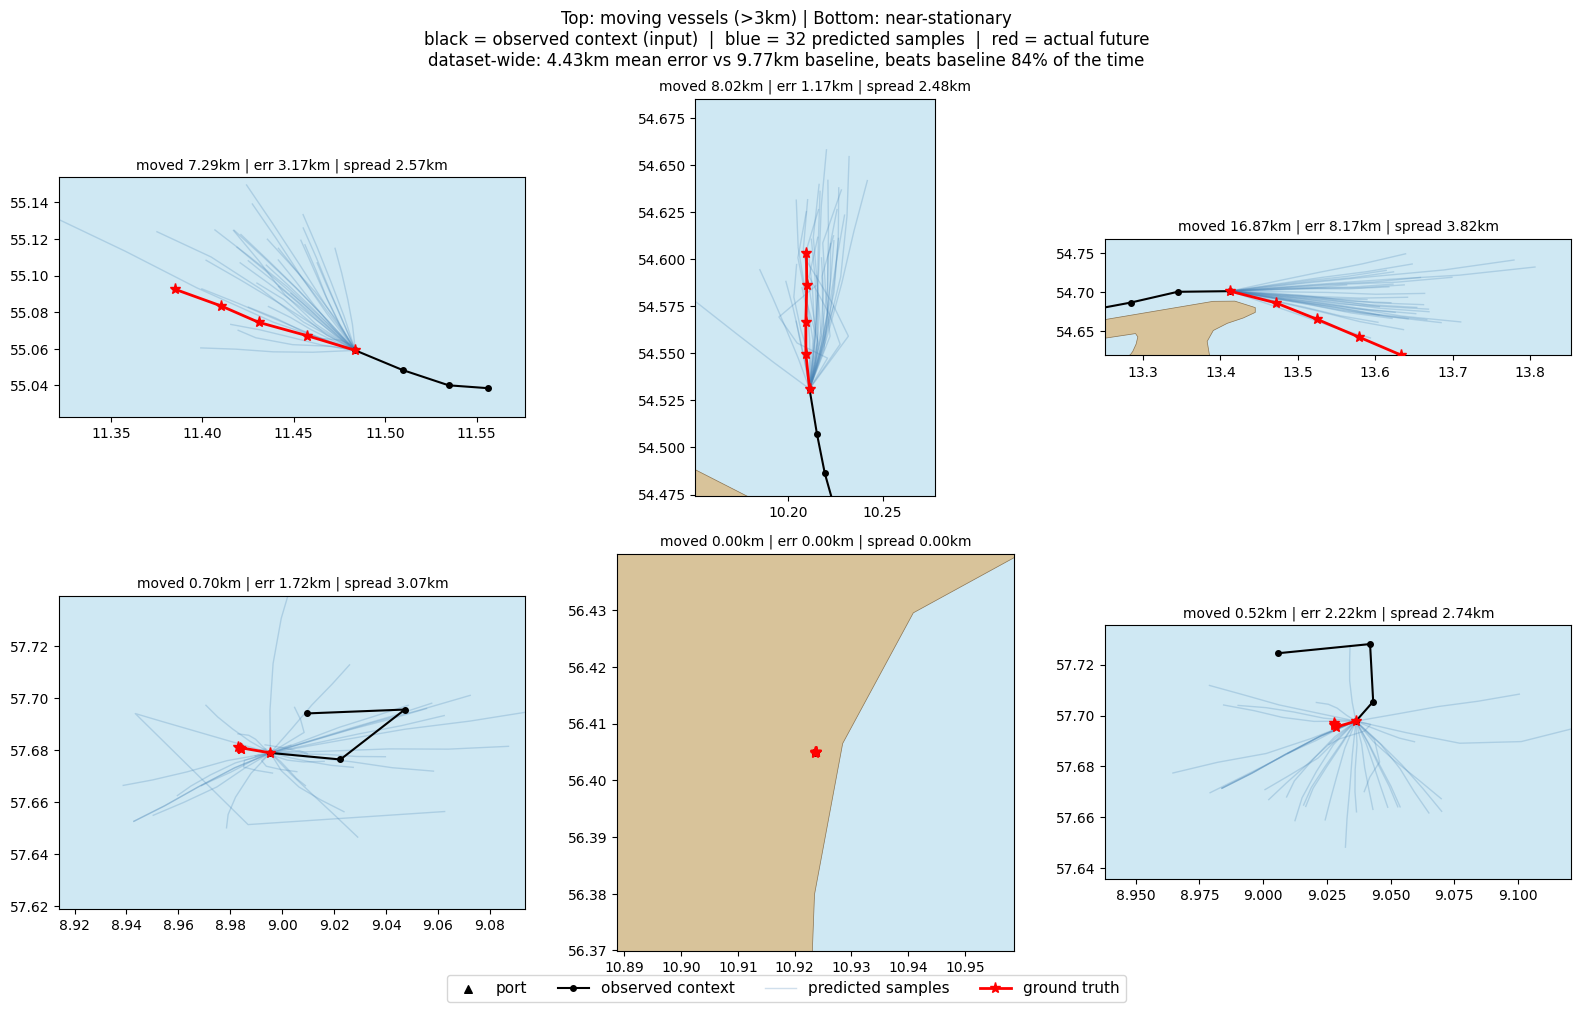

In [7]:
rng = np.random.default_rng(0)

# classify all windows, then sample randomly from each group
moving, stationary = [], []
for i in range(len(combined)):
    ctx_i, target_i = combined[i]
    ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
    lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2].cpu().numpy()
    tf = target_i[-1].cpu().numpy()
    d = haversine_km(lp[0], lp[1], tf[0], tf[1])
    (moving if d > 3.0 else stationary).append(i)

print(f"{len(moving)} moving windows, {len(stationary)} stationary windows")

pick_moving = rng.choice(moving, size=3, replace=False)
pick_stationary = rng.choice(stationary, size=3, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, i in zip(axes.flat, list(pick_moving) + list(pick_stationary)):
    plot_prediction(model, combined, i, norm_scale, land_polygons, ports, ax=ax)

# one shared legend, since per-panel legends clutter the grid
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Top: moving vessels (>3km) | Bottom: near-stationary\n'
    'black = observed context (input)  |  blue = 32 predicted samples  |  red = actual future\n'
    f'dataset-wide: {errs.mean():.2f}km mean error vs {disps.mean():.2f}km baseline, '
    f'beats baseline {100*(errs < disps).mean():.0f}% of the time',
    fontsize=12
)
fig.tight_layout()
plt.show()

window 445


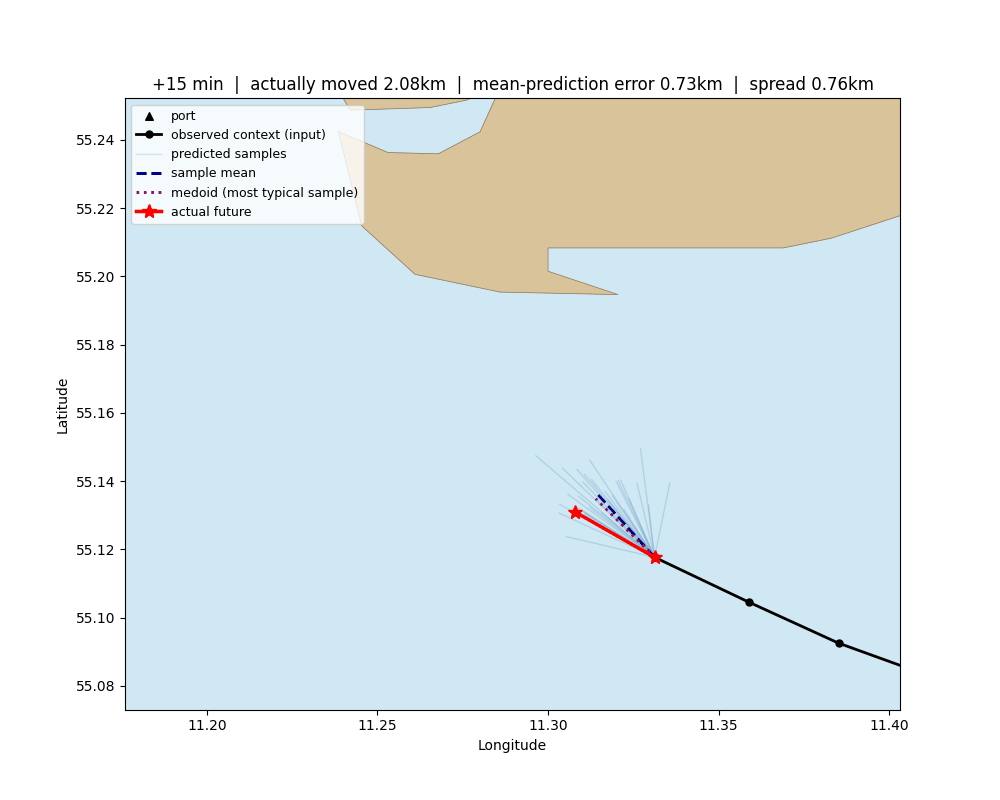

In [8]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage


def medoid_sample(samples_np):
    """
    Index of the sample with minimum total distance to all other samples.
    Unlike the mean, the medoid is an ACTUAL sampled path, so it's always
    physically plausible -- the mean can land somewhere no individual
    sample went (e.g. straight through an obstacle if the distribution is
    genuinely bimodal around it).
    """
    S = samples_np.shape[0]
    flat = samples_np.reshape(S, -1)
    d = np.linalg.norm(flat[:, None, :] - flat[None, :, :], axis=-1)
    return int(d.sum(axis=1).argmin())


def animate_prediction(model, dataset, idx, norm_scale, land_polygons, ports,
                        n_samples=32, interval_ms=700, min_window_deg=0.05,
                        figsize=(10, 8), out_path='prediction.gif'):
    """
    Animates one forecast window step by step. Context path is static;
    each frame reveals one more forecast step of the sampled futures
    (blue), the mean/medoid summaries, and the true future (red).
    """
    ctx, target = dataset[idx]
    ego_idx = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
    last_pos = ctx[-1]['vessel'].x[ego_idx[-1], :2]

    with torch.no_grad():
        samples = model(ctx, ego_idx, n_samples=n_samples, training=False)
        samples_real = samples * norm_scale + last_pos

    context_xy = np.array([d['vessel'].x[ego_idx[t], :2].cpu().numpy() for t, d in enumerate(ctx)])
    samples_np = samples_real[0].cpu().numpy()
    truth_np = target.cpu().numpy()
    future_len = truth_np.shape[0]

    mean_path = samples_np.mean(axis=0)
    med_path = samples_np[medoid_sample(samples_np)]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('#cfe8f3')
    for poly in land_polygons:
        xs, ys = poly.exterior.xy
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='#d8c39a',
                                 edgecolor='#8a7350', linewidth=0.5, zorder=1))
    ax.scatter([p[0] for p in ports], [p[1] for p in ports], s=30, c='black',
               marker='^', zorder=2, label='port')
    ax.plot(context_xy[:, 0], context_xy[:, 1], c='black', marker='o', markersize=5,
            linewidth=2, label='observed context (input)', zorder=5)

    sample_lines = [ax.plot([], [], c='steelblue', alpha=0.22, linewidth=1, zorder=2,
                             label='predicted samples' if s == 0 else None)[0]
                     for s in range(samples_np.shape[0])]
    mean_line, = ax.plot([], [], c='darkblue', linewidth=2, linestyle='--',
                          label='sample mean', zorder=6)
    med_line, = ax.plot([], [], c='purple', linewidth=2, linestyle=':',
                         label='medoid (most typical sample)', zorder=6)
    truth_line, = ax.plot([], [], c='red', marker='*', markersize=10, linewidth=2.5,
                           label='actual future', zorder=7)

    all_xy = np.vstack([context_xy, samples_np.reshape(-1, 2), truth_np])
    lon_range = max(all_xy[:, 0].max() - all_xy[:, 0].min(), min_window_deg)
    lat_range = max(all_xy[:, 1].max() - all_xy[:, 1].min(), min_window_deg)
    cx, cy = all_xy[:, 0].mean(), all_xy[:, 1].mean()
    ax.set_xlim(cx - lon_range/2 - 0.01, cx + lon_range/2 + 0.01)
    ax.set_ylim(cy - lat_range/2 - 0.01, cy + lat_range/2 + 0.01)
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(loc='upper left', fontsize=9)
    title = ax.set_title('')

    start = context_xy[-1:]

    def update(frame):
        step = frame + 1
        for s, line in enumerate(sample_lines):
            p = np.vstack([start, samples_np[s, :step]])
            line.set_data(p[:, 0], p[:, 1])
        mp = np.vstack([start, mean_path[:step]])
        mean_line.set_data(mp[:, 0], mp[:, 1])
        dp = np.vstack([start, med_path[:step]])
        med_line.set_data(dp[:, 0], dp[:, 1])
        tp = np.vstack([start, truth_np[:step]])
        truth_line.set_data(tp[:, 0], tp[:, 1])

        center = samples_np[:, step-1, :].mean(axis=0)
        spread = np.mean([haversine_km(center[0], center[1], p[0], p[1])
                           for p in samples_np[:, step-1, :]])
        err = haversine_km(center[0], center[1], truth_np[step-1, 0], truth_np[step-1, 1])
        moved = haversine_km(start[0, 0], start[0, 1], truth_np[step-1, 0], truth_np[step-1, 1])
        title.set_text(f'+{step*15} min  |  actually moved {moved:.2f}km  |  '
                        f'mean-prediction error {err:.2f}km  |  spread {spread:.2f}km')
        return sample_lines + [mean_line, med_line, truth_line, title]

    anim = animation.FuncAnimation(fig, update, frames=future_len,
                                    interval=interval_ms, blit=False)
    anim.save(out_path, writer='pillow', fps=1000/interval_ms)
    plt.close(fig)
    return out_path


# pick a moving window at random and animate it
i = int(rng.choice(moving))
gif_path = animate_prediction(model, combined, i, norm_scale, land_polygons, ports,
                               out_path='prediction.gif')
print(f'window {i}')
IPImage(filename=gif_path)

In [9]:
worst_i, worst_err = None, -1
with torch.no_grad():
    for i in moving:
        ctx_i, target_i = combined[i]
        ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
        lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2]
        s = model(ctx_i, ego_i, n_samples=32, training=False) * norm_scale + lp
        c = s[0, :, -1, :].mean(dim=0).cpu().numpy()
        tf = target_i[-1].cpu().numpy()
        e = haversine_km(c[0], c[1], tf[0], tf[1])
        if e > worst_err:
            worst_err, worst_i = e, i

print(f'worst window: {worst_i}, error {worst_err:.2f}km')
animate_prediction(model, combined, worst_i, norm_scale, land_polygons, ports, out_path='worst.gif')

worst window: 234, error 52.90km


'worst.gif'

In [10]:
from train import split_vessels_train_val

# reproduce train.py's exact vessel selection and split
good_vessels_full = select_ego_vessels_stratified(
    ais_df, min_pings=40, sog_threshold_knots=2.0,
    n_underway=150, n_stationary=150,   # must match the training run
)
train_ids, val_ids = split_vessels_train_val(good_vessels_full, val_fraction=0.2, seed=42)
print(f"{len(train_ids)} train, {len(val_ids)} held-out")

# build datasets from held-out vessels ONLY
val_datasets = []
for ego_mmsi in val_ids:
    snaps, ego_steps = build_snapshot_sequence(
        ais_snapshots, mesh_node_features, mesh_edge_index, ego_mmsi,
        mesh_x_tensor=mesh_x_tensor, mesh_edge_tensor=mesh_edge_tensor, mesh_tree=mesh_tree,
    )
    snaps = [d.to(device) for d in snaps]
    ds = VesselSequenceDataset(snaps, ego_steps, seq_len=4, future_len=4)
    if len(ds) > 0:
        val_datasets.append(ds)

combined_val = ConcatDataset(val_datasets)
print(f"held-out windows: {len(combined_val)}")

240 train, 60 held-out
held-out windows: 2221


held-out: 918 moving, 1303 stationary windows
held-out window 2078


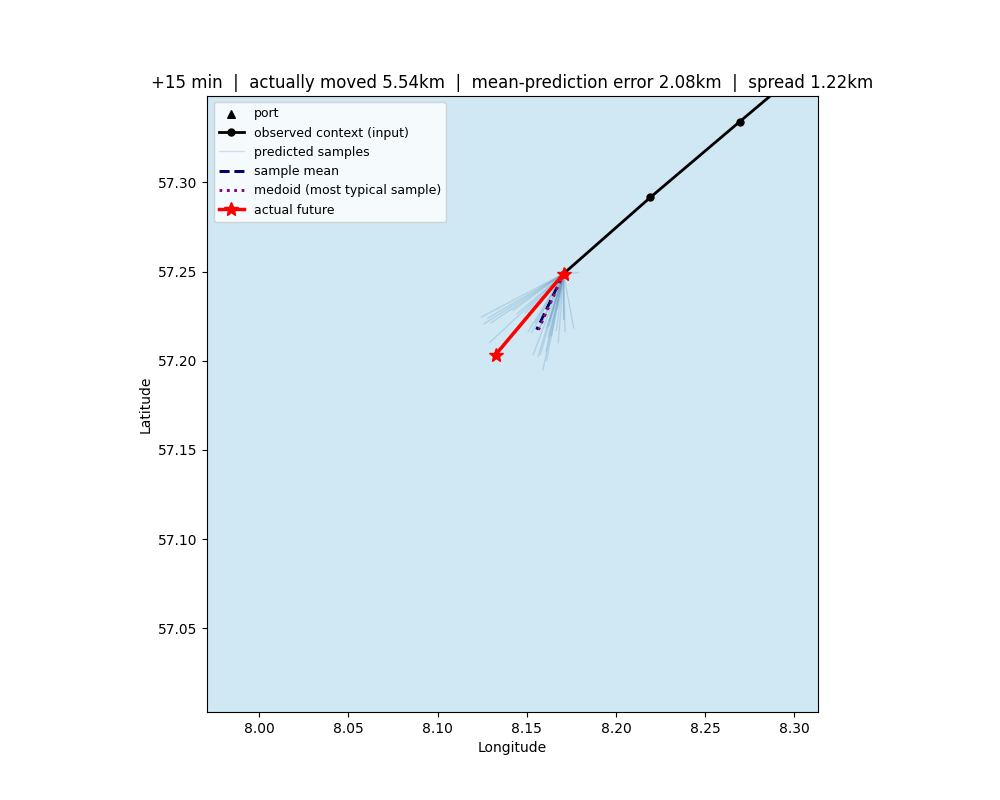

In [11]:
# classify held-out windows by how far the vessel actually moved
moving_val, stationary_val = [], []
for i in range(len(combined_val)):
    ctx_i, target_i = combined_val[i]
    ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
    lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2].cpu().numpy()
    tf = target_i[-1].cpu().numpy()
    d = haversine_km(lp[0], lp[1], tf[0], tf[1])
    (moving_val if d > 3.0 else stationary_val).append(i)

print(f"held-out: {len(moving_val)} moving, {len(stationary_val)} stationary windows")

# animate a random held-out moving vessel
rng = np.random.default_rng(0)
i = int(rng.choice(moving_val))
gif_path = animate_prediction(model, combined_val, i, norm_scale, land_polygons, ports,
                               out_path='prediction_heldout.gif')
print(f'held-out window {i}')
IPImage(filename=gif_path)

held-out stationary window 883


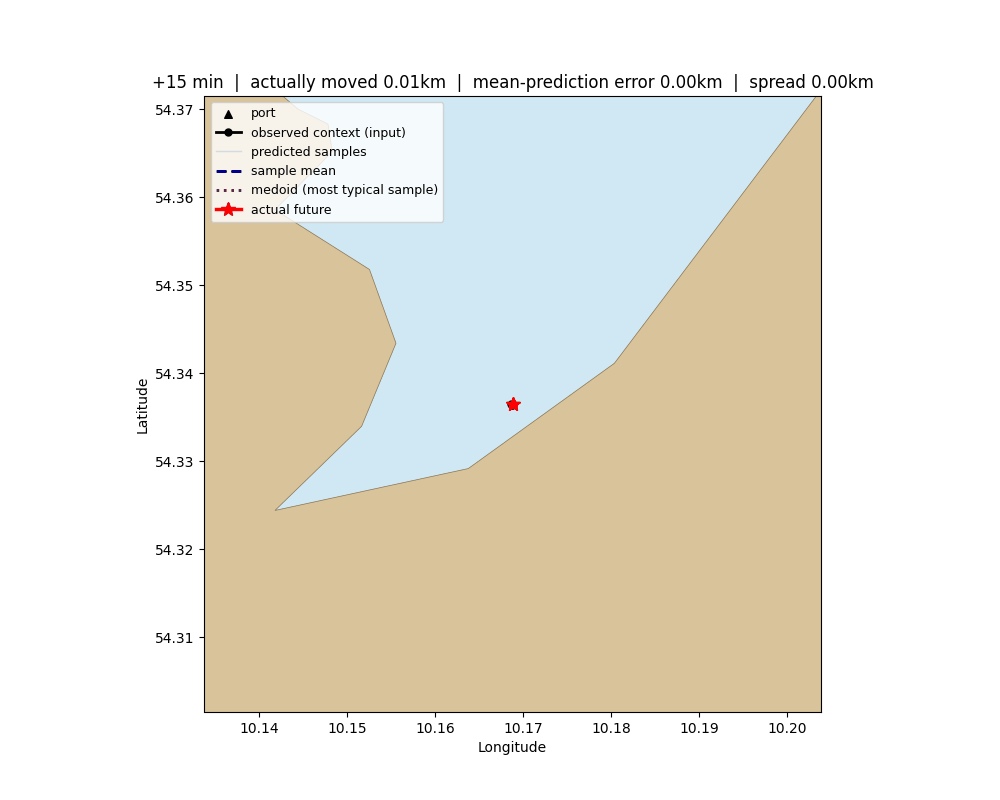

In [12]:
i = int(rng.choice(stationary_val))
gif_path = animate_prediction(model, combined_val, i, norm_scale, land_polygons, ports,
                               out_path='prediction_heldout_stationary.gif')
print(f'held-out stationary window {i}')
IPImage(filename=gif_path)

In [13]:
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 232,136


total moving windows: 1073
beats baseline: 78.8%
mean error: 6.93km | mean movement: 11.56km

factor                          worst 20%     best 20%    ratio
----------------------------------------------------------------
turn_deg                            40.87        10.09     4.05
speed_var                            0.01         0.00     3.12
dist_to_port_km                     83.65        87.04     0.96
n_vessels_in_snapshot             3362.19      3228.13     1.04
sog_knots                            5.73         7.53     0.76
moved_km                             6.35        13.22     0.48
spread_km                            3.07         3.53     0.87


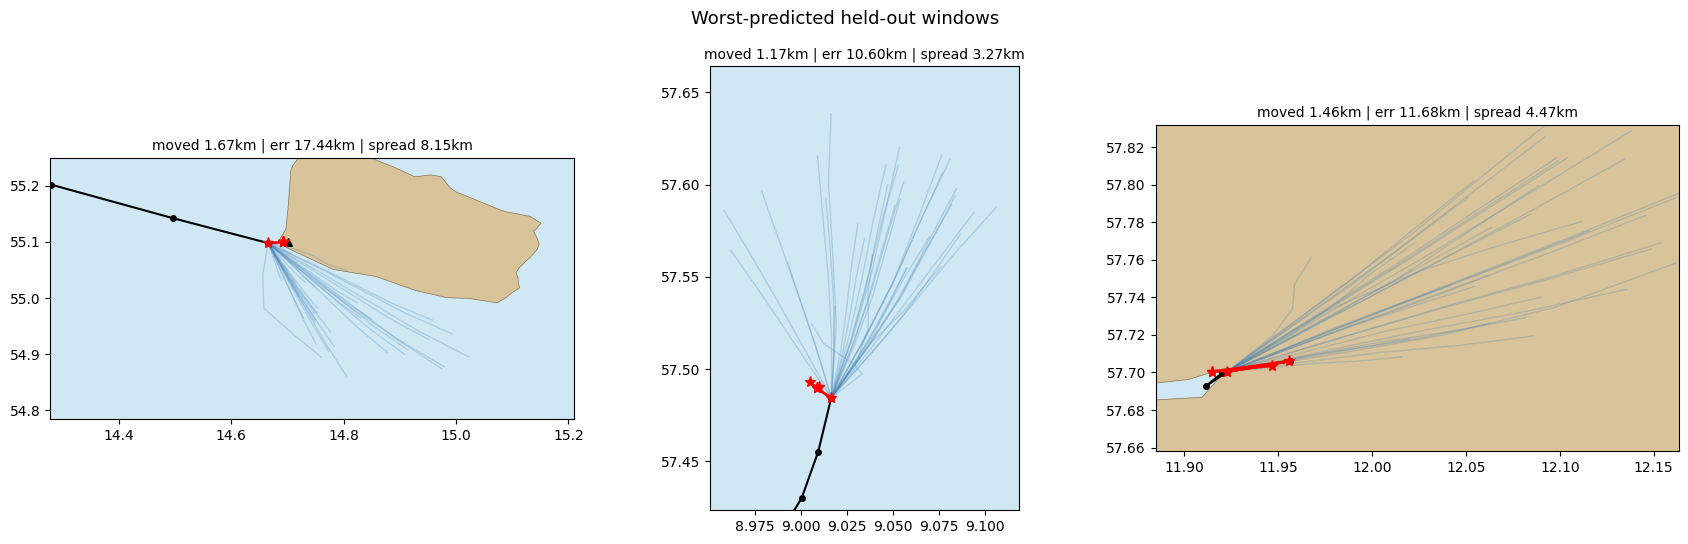

In [14]:
import pandas as pd


def turn_angle_deg(context_xy):
    """
    How much the vessel turned across the last two context steps.
    Computed from actual positions rather than the COG field, since COG
    can be noisy or stale for slow-moving vessels.
    """
    if len(context_xy) < 3:
        return 0.0
    v1 = context_xy[-2] - context_xy[-3]
    v2 = context_xy[-1] - context_xy[-2]
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-9 or n2 < 1e-9:
        return 0.0
    cos = np.clip(np.dot(v1, v2) / (n1 * n2), -1, 1)
    return float(np.degrees(np.arccos(cos)))


def speed_variability(context_xy):
    """Std of per-step displacement -- high means the vessel was
    accelerating/decelerating rather than holding a steady speed."""
    if len(context_xy) < 3:
        return 0.0
    steps = [np.linalg.norm(context_xy[i+1] - context_xy[i]) for i in range(len(context_xy) - 1)]
    return float(np.std(steps))


def analyze_failures(model, dataset, norm_scale, ports, n_samples=32, min_move_km=1.0):
    """
    Scores every window and records candidate explanatory factors, so
    'why does it fail' becomes an evidence question rather than a guess.
    """
    port_arr = np.array(ports)
    records = []
    model.eval()
    with torch.no_grad():
        for i in range(len(dataset)):
            ctx, target = dataset[i]
            ego_idx = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
            last_pos = ctx[-1]['vessel'].x[ego_idx[-1], :2]

            samples = model(ctx, ego_idx, n_samples=n_samples, training=False)
            samples_real = samples * norm_scale + last_pos

            context_xy = np.array([d['vessel'].x[ego_idx[t], :2].cpu().numpy()
                                    for t, d in enumerate(ctx)])
            last_np = last_pos.cpu().numpy()
            true_final = target[-1].cpu().numpy()
            pred_final = samples_real[0, :, -1, :].mean(dim=0).cpu().numpy()

            moved = haversine_km(last_np[0], last_np[1], true_final[0], true_final[1])
            if moved < min_move_km:
                continue

            err = haversine_km(pred_final[0], pred_final[1], true_final[0], true_final[1])
            spread = np.mean([haversine_km(pred_final[0], pred_final[1], p[0], p[1])
                               for p in samples_real[0, :, -1, :].cpu().numpy()])

            d_port = np.min(np.sqrt((port_arr[:, 0] - last_np[0])**2 +
                                     (port_arr[:, 1] - last_np[1])**2)) * 111.0  # rough km

            records.append({
                'idx': i, 'moved_km': moved, 'err_km': err, 'spread_km': spread,
                'beats_baseline': err < moved,
                'turn_deg': turn_angle_deg(context_xy),
                'speed_var': speed_variability(context_xy),
                'dist_to_port_km': d_port,
                'n_vessels_in_snapshot': ctx[-1]['vessel'].x.shape[0],
                'sog_knots': float(ctx[-1]['vessel'].x[ego_idx[-1], 2].cpu()),
            })
    return records


def summarize_failures(records, top_frac=0.2):
    """Compares the worst-predicted windows against the best, factor by
    factor, so any real pattern shows up as a gap between the groups."""
    df = pd.DataFrame(records)
    df['err_ratio'] = df['err_km'] / df['moved_km']  # <1 beats baseline
    df = df.sort_values('err_ratio', ascending=False)

    n = max(10, int(len(df) * top_frac))
    worst, best = df.head(n), df.tail(n)

    print(f"total moving windows: {len(df)}")
    print(f"beats baseline: {100*df['beats_baseline'].mean():.1f}%")
    print(f"mean error: {df['err_km'].mean():.2f}km | mean movement: {df['moved_km'].mean():.2f}km\n")
    print(f"{'factor':<28} {'worst 20%':>12} {'best 20%':>12} {'ratio':>8}")
    print('-' * 64)
    for col in ['turn_deg', 'speed_var', 'dist_to_port_km', 'n_vessels_in_snapshot',
                 'sog_knots', 'moved_km', 'spread_km']:
        w, b = worst[col].mean(), best[col].mean()
        print(f"{col:<28} {w:>12.2f} {b:>12.2f} {w/b if abs(b)>1e-9 else float('nan'):>8.2f}")
    return df


# run on held-out data
records = analyze_failures(model, combined_val, norm_scale, ports)
df = summarize_failures(records)

# visualize the worst cases
worst_indices = df.head(3)['idx'].astype(int).tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, i in zip(axes, worst_indices):
    plot_prediction(model, combined_val, i, norm_scale, land_polygons, ports, ax=ax)
fig.suptitle('Worst-predicted held-out windows', fontsize=13)
fig.tight_layout()
plt.show()

In [15]:
def count_windows_by_config(ais_snapshots, vessel_ids, seq_lens, future_lens):
    """
    How many training windows survive at each (seq_len, future_len)?
    A vessel needs seq_len+future_len CONSECUTIVE snapshots to yield a
    window, so both knobs shrink the usable dataset -- worth measuring
    before committing to a config.
    """
    timestamps = sorted(ais_snapshots.keys())
    ts_index = {ts: i for i, ts in enumerate(timestamps)}

    # per-vessel runs of consecutive timesteps
    runs_per_vessel = {}
    for mmsi in vessel_ids:
        present = sorted(ts_index[ts] for ts in timestamps if mmsi in ais_snapshots[ts])
        runs, cur = [], 1
        for a, b in zip(present[:-1], present[1:]):
            if b - a == 1:
                cur += 1
            else:
                runs.append(cur); cur = 1
        runs.append(cur)
        runs_per_vessel[mmsi] = runs

    print(f"{'seq_len':>8} {'future_len':>11} {'total_span':>11} {'windows':>10} {'vessels':>9}")
    print('-' * 54)
    results = {}
    for sl in seq_lens:
        for fl in future_lens:
            need = sl + fl
            total_windows, usable_vessels = 0, 0
            for mmsi, runs in runs_per_vessel.items():
                w = sum(max(0, r - need + 1) for r in runs)
                total_windows += w
                if w > 0:
                    usable_vessels += 1
            span_hr = need * 15 / 60
            print(f"{sl:>8} {fl:>11} {span_hr:>9.1f}hr {total_windows:>10} {usable_vessels:>9}")
            results[(sl, fl)] = (total_windows, usable_vessels)
    return results


results = count_windows_by_config(
    ais_snapshots, good_vessels.index,
    seq_lens=[4, 8, 12, 16, 24],
    future_lens=[4, 8, 12, 16, 24],
)

 seq_len  future_len  total_span    windows   vessels
------------------------------------------------------
       4           4       2.0hr       1177        32
       4           8       3.0hr       1029        31
       4          12       4.0hr        919        22
       4          16       5.0hr        831        21
       4          24       7.0hr        674        16
       8           4       3.0hr       1029        31
       8           8       4.0hr        919        22
       8          12       5.0hr        831        21
       8          16       6.0hr        747        21
       8          24       8.0hr        611        15
      12           4       4.0hr        919        22
      12           8       5.0hr        831        21
      12          12       6.0hr        747        21
      12          16       7.0hr        674        16
      12          24       9.0hr        551        15
      16           4       5.0hr        831        21
      16           8       

In [16]:
step_errors = [[] for _ in range(4)]
with torch.no_grad():
    for i in moving_val:
        ctx_i, target_i = combined_val[i]
        ego_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
        lp = ctx_i[-1]['vessel'].x[ego_i[-1], :2]
        s = model(ctx_i, ego_i, n_samples=32, training=False) * norm_scale + lp
        pred = s[0].mean(dim=0).cpu().numpy()
        truth = target_i.cpu().numpy()
        for step in range(4):
            step_errors[step].append(haversine_km(pred[step,0], pred[step,1],
                                                    truth[step,0], truth[step,1]))

for step, errs in enumerate(step_errors):
    print(f"+{(step+1)*15:>3} min: mean error {np.mean(errs):.2f}km")

+ 15 min: mean error 1.59km
+ 30 min: mean error 3.43km
+ 45 min: mean error 5.43km
+ 60 min: mean error 7.58km


In [6]:
import viz

ctx = viz.setup(n_underway=300, n_stationary=300, seq_len=12, future_len=8)
model, norm_scale, meta = viz.load_checkpoint_model('checkpoints/checkpoint_large.pt')
print(meta)

viz.evaluate(model, ctx.combined_val, norm_scale)
viz.per_step_errors(model, ctx.combined_val, norm_scale)

mesh: 5581 nodes, 16717 edges
AIS: 29204133 records, 96 timestamps
vessels: 480 train, 120 held-out
held-out windows: 3255 across 73 vessels
{'epoch': 4, 'avg_loss': 0.8352975123943275, 'hidden': 128, 'n_layers': 4, 'vessel_in': 12, 'future_len': 4}
  n_windows: 3255
  spread_correlation: 0.717
  n_moving: 1108
  model_mean_error_km: 12.889
  baseline_mean_error_km: 17.192
  beats_baseline_pct: 76.986


IndexError: index 4 is out of bounds for axis 0 with size 4

In [ ]:
fig = viz.plot_grid(model, ctx.combined_val, norm_scale, ctx)

moving, stationary = viz.classify_windows(model, ctx.combined_val, norm_scale)
gif = viz.animate_prediction(model, ctx.combined_val, moving[0], norm_scale, ctx)
from IPython.display import Image; Image(filename=gif)

records = viz.analyze_failures(model, ctx.combined_val, norm_scale, ctx)
df = viz.summarize_failures(records)

In [ ]:
import numpy as np
rng = np.random.default_rng(0)
i = int(rng.choice(moving))
gif = viz.animate_prediction(model, ctx.combined_val, i, norm_scale, ctx,
                              out_path=f'prediction_{i}.gif')
Image(filename=gif)